In [1]:
import nltk
import numpy as np
import pandas as pd
import os
import re
import string
import Basic_functions as bf  #Homemade script.
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split


from nltk import word_tokenize
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, RandomizedSearchCV 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from nltk.stem import SnowballStemmer

stopwords_danish = np.genfromtxt(r"txt_files\\stopord.txt", dtype = "str", encoding="utf-8")
default_stopwords = set(stopwords.words('english'))

extended_stopwords = default_stopwords.union(stopwords_danish)

print('Packages loaded')

Packages loaded


In [11]:
def process_txt_files(folder_path):
    """
    Process .txt files to:
    1. Extract "Organisationer og bevægelser:" lines (with filename, line number, cleaned text).
    2. Extract 4-digit years from the same lines.
    3. Extract general text after "\n\n\n" (cleaned).
    4. Return a list of tuples: (filename, line_number, party_text, general_text, [years])
    """
    extracted_data = []

    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    # Check if the file contains the target phrase (case-insensitive)
                    file_content = file.read()
                    if "organisationer og bevægelser:" not in file_content.lower():
                        continue  # Skip files without the phrase

                    # Reset file pointer to read lines again
                    file.seek(0)
                    for line_number, line in enumerate(file, start=1):
                        # Case-insensitive search for the party pattern
                        party_match = re.search(
                            r'organisationer og bevægelser:\s*(.*)',
                            line,
                            re.IGNORECASE
                        )
                        if party_match:
                            # Extract raw text after ":"
                            raw_party_text = party_match.group(1).strip()

                            # Clean the party text:
                            # 1. Replace escaped newlines (\\n) with spaces, then remove all newlines
                            party_text = raw_party_text.replace('\\n', ' ').replace('\n', ' ')
                            # 2. Lowercase, keep letters (including æøå), spaces, and remove apostrophes and ellipses
                            party_text = re.sub(r"[^a-zA-ZæøåÆØÅ\s']", '', party_text.lower())
                            party_text = party_text.replace("'", "").replace('...', '')
                            # 3. Collapse multiple spaces
                            party_text = ' '.join(party_text.split())

                            year_part = file_content.split('\n', 2)
                            year_after_marker = (year_part[1].split('-',1))[0]
                            cleaned_year = year_after_marker.replace('Date: ', "")
                            try:
                                txt_year = float(cleaned_year)
                            except:
                                txt_year = float(0)

                            # Extract general text after "\n\n\n" (if exists)
                            general_text = ""
                            if "\n\n\n" in file_content:
                                parts = file_content.split('\n\n\n', 1)
                                general_text = parts[1]
                            else:
                                general_text = file_content  # Fallback

                            # Clean the general text:
                            # 1. Replace escaped newlines (\\n) with spaces, then remove all newlines
                            general_text = general_text.replace('\\n', ' ').replace('\n', ' ')
                            # 2. Lowercase, keep letters (including æøå), spaces, and remove ellipses
                            general_text = re.sub(r'[^a-zA-ZæøåÆØÅ\s]', '', general_text.lower())
                            general_text = general_text.replace('...', '')  # Remove ellipses
                            # 3. Collapse multiple spaces
                            general_text = ' '.join(general_text.split())

                            extracted_data.append((
                                filename,
                                line_number,
                                party_text,
                                general_text,
                                txt_year
                            ))
            except Exception as e:
                print(f"Error reading {filename}: {e}")

    return extracted_data

# Example usage:
folder_path = r'..\ML2026_Files\Speeches'  # Replace with your folder path
df = process_txt_files(folder_path)

# Print the extracted data
for i, (filename, line_number, party_text, general_text, years) in enumerate(df):
    print(f"Match {i + 1}:")
    print(f"  File: {filename}")
    print(f"  Line: {line_number}")
    print(f"  Party: {party_text}")
    print(f"  General Text: {general_text[:100]}...")  # Print first 100 chars
    print(f"  Years: {years}\n")


Match 1:
  File: Aksel_Larsens_1._maj-tale.txt
  Line: 4
  Party: danmarks kommunistiske parti
  General Text: to spørgsmål trænger sig på frem for alle andre det ene er bestræbelserne for at få standset prøvesp...
  Years: 1958.0

Match 2:
  File: Aksel_Larsens_1._maj-tale.txt
  Line: 5
  Party: socialistisk folkeparti
  General Text: to spørgsmål trænger sig på frem for alle andre det ene er bestræbelserne for at få standset prøvesp...
  Years: 1958.0

Match 3:
  File: Aksel_Larsens_badtale.txt
  Line: 3
  Party: danmarks kommunistiske parti
  General Text: klassefæller valget gælder kapitalisme eller socialisme sammenbrud eller opbygning lønslaveri eller ...
  Years: 1931.0

Match 4:
  File: Aksel_Larsens_manifesttale.txt
  Line: 3
  Party: danmarks kommunistiske parti
  General Text: som følge af kapitalisme og udbytning som følge af mange års forfejlet politik og som følge af krige...
  Years: 1940.0

Match 5:
  File: Aksel_Larsens_tale_i_Folketinget.txt
  Line: 3
  Party: danmark

In [12]:
df = pd.DataFrame(df, columns = ['file', 'line', 'party', 'text', 'year'])
df

,file,line,party,text,year
0,Aksel_Larsens_1._maj-tale.txt,4,danmarks kommunistiske parti,to spørgsmål trænger sig på frem for alle andr...,1958.0
1,Aksel_Larsens_1._maj-tale.txt,5,socialistisk folkeparti,to spørgsmål trænger sig på frem for alle andr...,1958.0
2,Aksel_Larsens_badtale.txt,3,danmarks kommunistiske parti,klassefæller valget gælder kapitalisme eller s...,1931.0
3,Aksel_Larsens_manifesttale.txt,3,danmarks kommunistiske parti,som følge af kapitalisme og udbytning som følg...,1940.0
4,Aksel_Larsens_tale_i_Folketinget.txt,3,danmarks kommunistiske parti,det egentlige danmark jeg ønsker at sige til d...,1940.0
...,...,...,...,...,...
2106,Villy_Søvndals_tale_ved_Socialistisk_Folkparti...,4,socialistisk folkeparti,velkommen til sfs landsmøde velkommen til jer ...,2006.0
2107,Vivi_Jelstrups_baltale.txt,4,regnbuebevægelsen,hej alle sammen som i allerede ved vil vi om l...,2013.0
2108,Zenia_Stampes_grundlovstale.txt,4,radikale venstre,når mine børn spørger hvad jeg arbejder for så...,2025.0
2109,Zenia_Stampes_nytarstale_til_kulturen.txt,4,radikale venstre,jeg glæder mig til for jeg tror det bliver et ...,2019.0


In [15]:
def preprocess(text, min_word_length=3, max_word_length=30):
    
    stemmer = SnowballStemmer(language='danish')
    
    tokens = word_tokenize(text, language = 'danish', preserve_line=False)

    tokens = [
        word for word in tokens
        if (word.isalpha() and
            word not in string.punctuation and
            min_word_length <= len(word) <= max_word_length)
    ]
    
    tokens = [word for word in tokens if word.isalpha() and word not in extended_stopwords]
    
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)
    

####################################

start = time.time()

df_clean = pd.DataFrame({
    'text': df['text'].apply(preprocess),
    'party': df['party'],
    'year': df['year']
})

    
stop = time.time()

print(f'Time preprocessing: {(stop-start)/60:3f} minuttes')

Time preprocessing: 0.739641 minuttes


In [16]:
df_clean

,text,party,year
0,spørgsmål træng frem bestræb stands prøvespræn...,danmarks kommunistiske parti,1958.0
1,spørgsmål træng frem bestræb stands prøvespræn...,socialistisk folkeparti,1958.0
2,klassefæl valg gæld kapitalism socialism samme...,danmarks kommunistiske parti,1931.0
3,kapitalism udbytning forfejl politik krig dera...,danmarks kommunistiske parti,1940.0
4,egent danmark jeg ønsk såkald national samling...,danmarks kommunistiske parti,1940.0
...,...,...,...
2106,velkom sfs landsmød velkom land bruxel sfuern ...,socialistisk folkeparti,2006.0
2107,tænd bål brænd skab skab følt begræns indeluk ...,regnbuebevægelsen,2013.0
2108,børn spørg jeg arbejd plej jeg trued dyr plant...,radikale venstre,2025.0
2109,jeg glæd jeg tror rigt dansk kulturliv jeg tro...,radikale venstre,2019.0


In [31]:
with open("..\ML2026_Files\Speeches\Alexander_den_Stores_tale_ved_Opis.txt", 'r', encoding='utf-8') as file:
                    # Check if the file contains the target phrase (case-insensitive)
                    Alex = file.read()
                    Alex = Alex.split('\n\n')[1]
                    Alex = preprocess(Alex)
print(Alex)

makedon jeg hold tal forhindr hjemrejs skyld afsted overvej tjent tjent afsted men jeg pas begynd tal filip for magt flakked hjælpeløs gik klædt dyreskind køer græs bjerg søl kvægflok knap beskyt illyr tribal thrak han gav ordent kap sted skind ledt bjerg slet dér lært forsvar ordent omkringbo barbar stol lang natur områd ufremkom redning han indbyg bystat indført lov ord fra slav undersåt hersk barbar hærg plyndr ejendom desud tilføjed del thraki makedoni åbned handel bedst belig kyststrækning sikkert arbejd min hersk thessal dødbang han ydmyged foke sikred let fremkom vej hella utilgæng han ydmyged athen theban forsøg underlæg makedoni dengang tog bestræb for sted betal skat athen underlag theban sikr sikker han tog pelopon ordned forhold udnævnt general uindskrænk magt felttog pers derved skaffed makedoni væld berøm det udgangspunk utro sær forhold udret fra arved jeg bægr guld sølv knap talent skatkam gæld talent derudov optog jeg lån talent jeg brød land engang råd kvæg mark strak

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Geniet\AppData\Local\Temp\ipykernel_5724\394576336.py:1: SyntaxWarning: invalid escape sequence '\M'
  with open("..\ML2026_Files\Speeches\Alexander_den_Stores_tale_ved_Opis.txt", 'r', encoding='utf-8') as file:


In [134]:
with open(r"", 'r', encoding='utf-8') as file:
                    # Check if the file contains the target phrase (case-insensitive)
                    KB = file.read()
                    KB = preprocess(KB)
KB_tfidf = vectorizer.transform(pd.DataFrame([KB], columns=['text']))
label_KB = model.predict(KB_tfidf)
print(y.iloc[label_KB])

14    liberal alliance
Name: party, dtype: object


In [132]:
with open(r"C:\Users\Geniet\AppliedML\AppML_Project\KB_tale_tekst.txt", 'r', encoding='utf-8') as file:
                    # Check if the file contains the target phrase (case-insensitive)
                    KB = file.read()
                    KB = preprocess(KB)
KB_tfidf = vectorizer.transform(pd.DataFrame([KB], columns=['text']))
label_KB = model.predict(KB_tfidf)
print(y.iloc[label_KB])

14    liberal alliance
Name: party, dtype: object


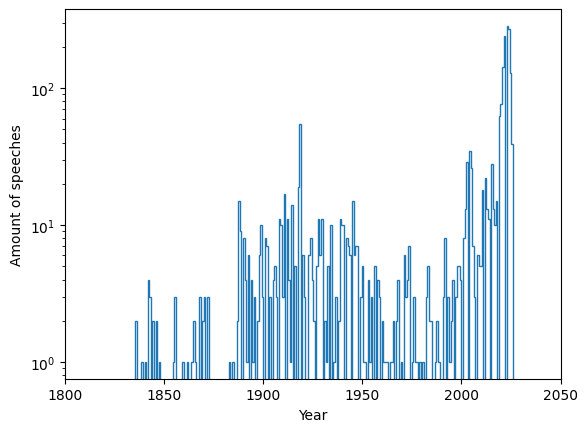

In [20]:
plt.hist(df_clean['year'], bins = 300, histtype = 'step')
plt.yscale('log')
plt.xlim(1800,2050)
plt.xlabel('Year')
plt.ylabel('Amount of speeches')
plt.show()

In [94]:
from scipy.sparse import hstack, csr_matrix

vectorizer = TfidfVectorizer(use_idf=False, min_df=3, max_df=0.8, lowercase=True, token_pattern=r'(?u)\b[A-Za-zæøå]+\b')
le = LabelEncoder()

X = (vectorizer.fit_transform(df_clean['text'])).astype(np.float32)  #pd.concat([X_text, X_year], axis=1)
y = df_clean['party']

y_encoded = le.fit_transform(y)
Unique, counts = np.unique(y, return_counts=True)
X = X[np.isin(y, Unique[counts >= 10], )]
y = y[np.isin(y, Unique[counts >= 10], )]
y_encoded = le.fit_transform(y)

print("TF-IDF matrix shape:", X.shape) 

TF-IDF matrix shape: (2051, 21408)


In [46]:
y_encoded.shape

(2051,)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [72]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

model = XGBClassifier(
    num_class=len(le.classes_), 
    eval_metric='mlogloss',
    max_depth=8,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42,
    early_stopping_rounds = 10,
    n_jobs = 1,
)

eval_set = [(X_train, y_train)]

model.fit(X_train, y_train, eval_set = eval_set, sample_weight = sample_weight)

[0]	validation_0-mlogloss:2.87272
[1]	validation_0-mlogloss:2.62255
[2]	validation_0-mlogloss:2.42321
[3]	validation_0-mlogloss:2.25578
[4]	validation_0-mlogloss:2.11022
[5]	validation_0-mlogloss:1.97818
[6]	validation_0-mlogloss:1.86038
[7]	validation_0-mlogloss:1.75759
[8]	validation_0-mlogloss:1.65964
[9]	validation_0-mlogloss:1.57216
[10]	validation_0-mlogloss:1.49162
[11]	validation_0-mlogloss:1.41640
[12]	validation_0-mlogloss:1.34425
[13]	validation_0-mlogloss:1.27738
[14]	validation_0-mlogloss:1.21450
[15]	validation_0-mlogloss:1.15514
[16]	validation_0-mlogloss:1.10212
[17]	validation_0-mlogloss:1.05460
[18]	validation_0-mlogloss:1.00809
[19]	validation_0-mlogloss:0.96442
[20]	validation_0-mlogloss:0.92425
[21]	validation_0-mlogloss:0.88521
[22]	validation_0-mlogloss:0.84952
[23]	validation_0-mlogloss:0.81568
[24]	validation_0-mlogloss:0.78343
[25]	validation_0-mlogloss:0.75402
[26]	validation_0-mlogloss:0.72684
[27]	validation_0-mlogloss:0.70068
[28]	validation_0-mlogloss:0.6

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=1, num_class=25, ...)

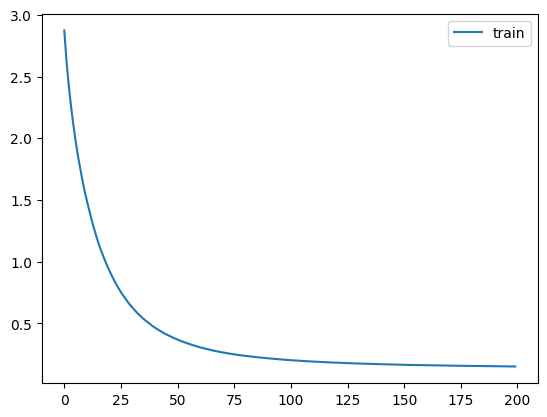

In [74]:
n_classes = len(le.classes_)
class_counts = np.bincount(y_test)
n_samples, n_features = X.shape
class_weights = len(y_test) / (n_classes * class_counts)
results = model.evals_result()

# plot learning curves
plt.plot(results['validation_0']['mlogloss'], label='train')
#plt.plot(results['validation_1']['rmse'], label='test')
# show the legend
plt.legend()
# show the plot
plt.show()

In [102]:
Alex_tfidf = vectorizer.transform(pd.DataFrame([Alex], columns=['text']))
label = model.predict(Alex_tfidf)
print(y.iloc[label])

14    liberal alliance
Name: party, dtype: object


In [104]:
y_score = model.predict_proba(X_test)
y_prob = model.predict(X_test)
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve

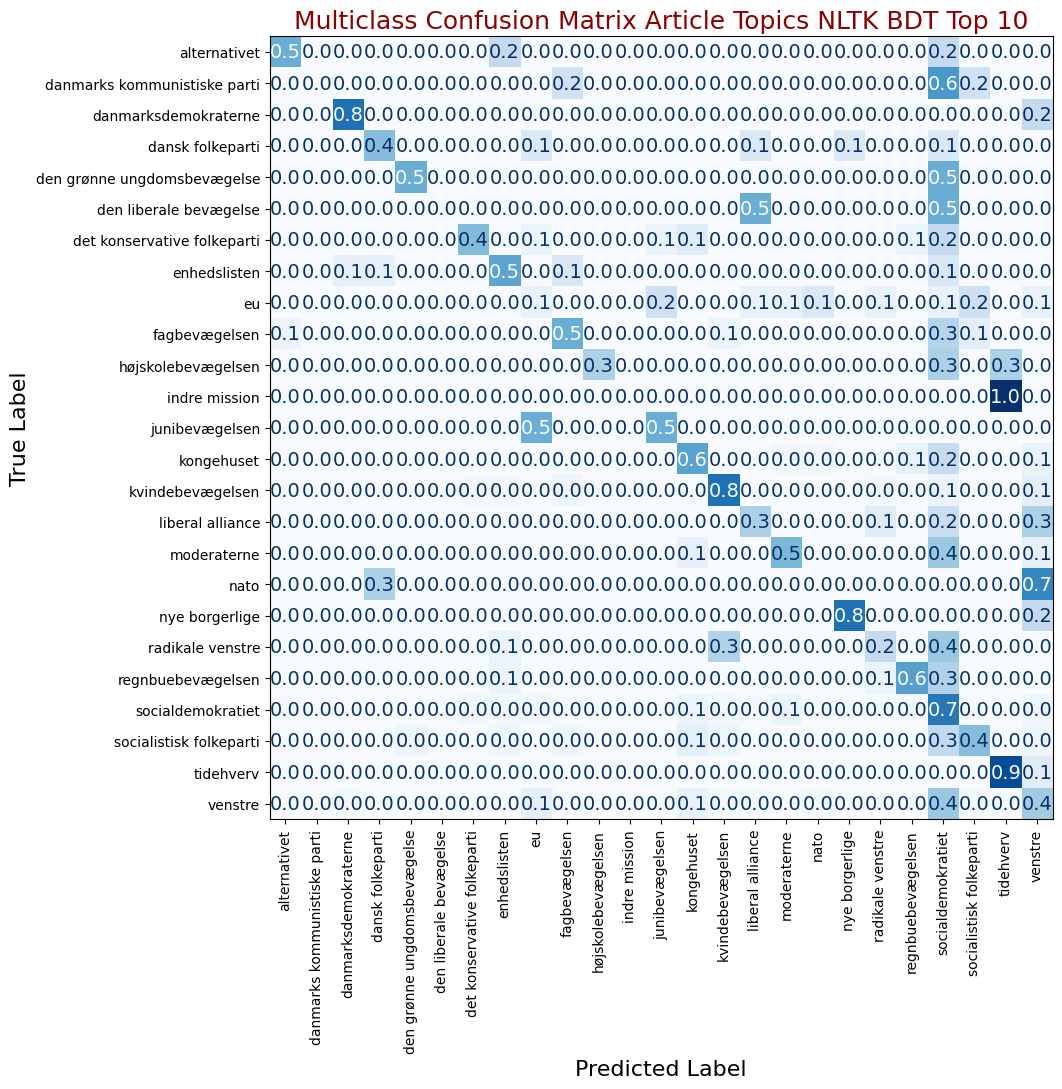

In [112]:
cm = confusion_matrix(
    y_test,
    y_prob,
    normalize="true"
)

# Force 2 decimals
cm = np.round(cm, 2)

classes = le.classes_

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(11,11))

disp.plot(
    ax=ax,
    xticks_rotation=0,
    cmap=plt.cm.Blues,
    colorbar=False,

    values_format=".1f"   # FORCE 2 DECIMALS
)

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Multiclass Confusion Matrix Article Topics NLTK BDT Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "Predicted Label",
    fontsize=16
)

plt.xticks(rotation = 90)
plt.ylabel(
    "True Label",
    fontsize=16
)
plt.tight_layout()

plt.savefig('Party_CFM.pdf')
plt.show()

<h1> One-vs-Rest multiclass ROC </h1>

In [300]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape  # (n_samples, n_classes)

(411, 25)

In [302]:
le.classes_

array(['alternativet', 'danmarks kommunistiske parti',
       'danmarksdemokraterne', 'dansk folkeparti',
       'den grønne ungdomsbevægelse', 'den liberale bevægelse',
       'det konservative folkeparti', 'enhedslisten', 'eu',
       'fagbevægelsen', 'højskolebevægelsen', 'indre mission',
       'junibevægelsen', 'kongehuset', 'kvindebevægelsen',
       'liberal alliance', 'moderaterne', 'nato', 'nye borgerlige',
       'radikale venstre', 'regnbuebevægelsen', 'socialdemokratiet',
       'socialistisk folkeparti', 'tidehverv', 'venstre'], dtype=object)

In [304]:
from sklearn.metrics import auc, roc_curve

# store the fpr, tpr, and roc_auc for all averaging strategies
fpr, tpr, roc_auc = dict(), dict(), dict()
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['micro']:.2f}")

Micro-averaged One-vs-Rest ROC AUC score:
0.92


Macro-averaged One-vs-Rest ROC AUC score:
0.89


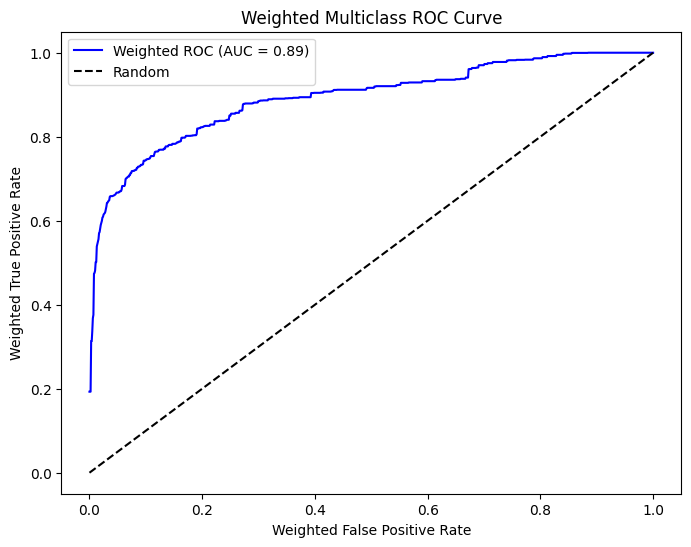

In [308]:
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr_grid = np.linspace(0.0, 1.0, 1000)

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(fpr_grid)

for i in range(n_classes):
    mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])# * class_weights[i] # linear interpolation

# Average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = fpr_grid
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['macro']:.2f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_grid, mean_tpr, label=f'Weighted ROC (AUC = {roc_auc["macro"]:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Weighted False Positive Rate')
plt.ylabel('Weighted True Positive Rate')
plt.title('Weighted Multiclass ROC Curve')
plt.legend()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

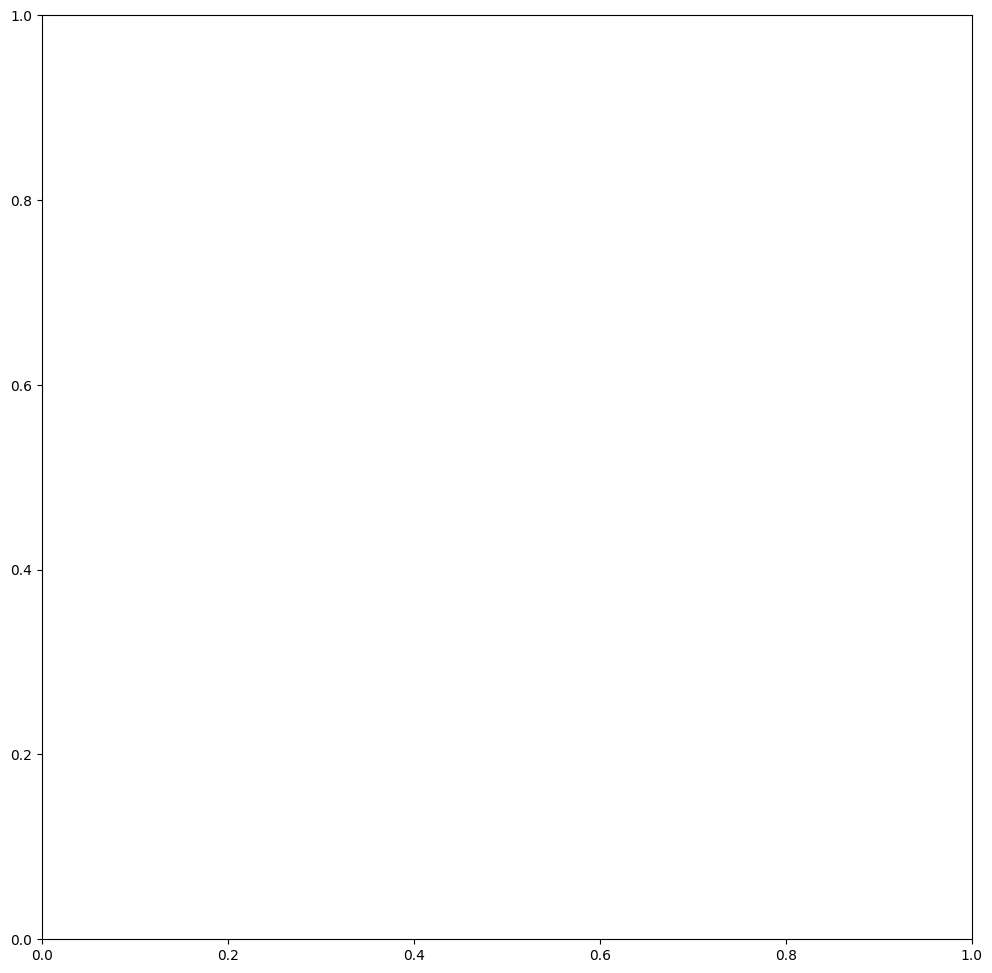

In [289]:
#https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html
from itertools import cycle

target_names = le.classes_

fig, ax = plt.subplots(figsize=(12, 12))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

#plt.plot(
#    fpr_grid,
#    tpr["macro"],
#    label=f"macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
#    color="navy",
#    linestyle=":",
#    linewidth=4,
#)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC curve for {target_names[class_id]}",
        #curve_kwargs=dict(color=color),
        ax=ax,
        plot_chance_level=(class_id == 2),
        despine=True,
    )

_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Extension of Receiver Operating Characteristic\nto One-vs-Rest multiclass",
)
plt.legend()

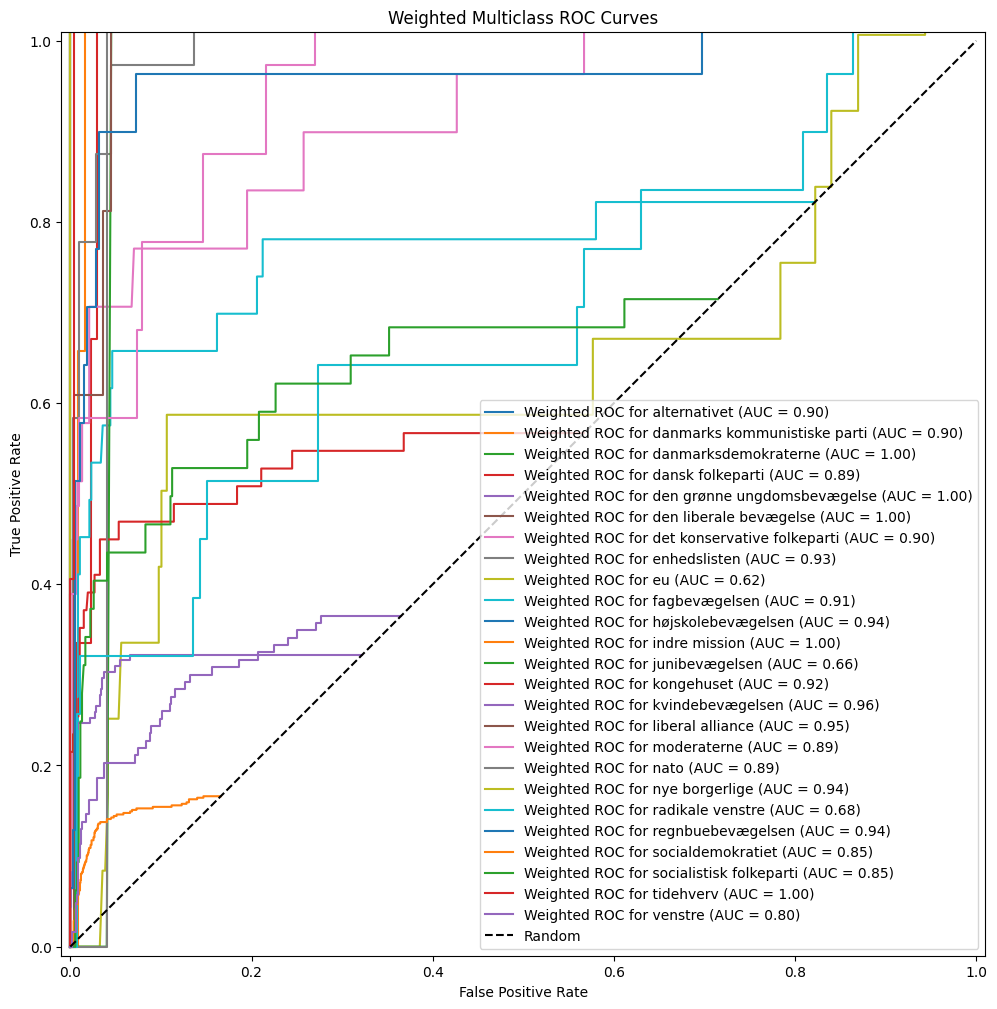

In [285]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot weighted ROC curves for each class
for class_id, color in zip(range(n_classes), colors):
    # Compute ROC curve for the current class
    fpr, tpr, _ = roc_curve(y_onehot_test[:, class_id], y_score[:, class_id])
    roc_auc = auc(fpr, tpr)

    # Weight the FPR and TPR by class frequency
    weighted_fpr = fpr * class_weights[class_id]
    weighted_tpr = tpr * class_weights[class_id]

    # Plot the weighted ROC curve
    RocCurveDisplay(
        fpr=weighted_fpr,
        tpr=weighted_tpr,
        roc_auc=roc_auc,
        estimator_name=f"ROC curve for {target_names[class_id]}",
    ).plot(ax=ax, name=f"Weighted ROC for {target_names[class_id]}")

# Plot chance level (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random')

# Customize plot
ax.set_title('Weighted Multiclass ROC Curves')
ax.legend()
plt.show()